![A soccer pitch for an international match.](./images/soccer-pitch.jpg)

We're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. We've been watching both men's and women's international soccer matches for a number of years, and our gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that our subscribers are bound to love, but we'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, we acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so we decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) since `2002-01-01`.

We create two datasets containing the results of every official men's and women's international football match since the 19th century, which we scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question we are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

We assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

In [1]:
%pip install pingouin

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats

In [3]:
women_results = pd.read_csv('data/women_results.csv', parse_dates=['date'])
men_results = pd.read_csv('data/men_results.csv', parse_dates=['date'])

# Filter data for FIFA World Cup matches since 2002-01-01
men_world_cup = men_results.loc[(men_results["date"] > "2002-01-01") & (men_results["tournament"].isin(["FIFA World Cup"]))].copy()
women_world_cup = women_results.loc[(women_results["date"] > "2002-01-01") & (women_results["tournament"].isin(["FIFA World Cup"]))].copy()

# Calculate total goals for each match
women_world_cup['total_goals'] = women_world_cup['home_score'] + women_world_cup['away_score']
men_world_cup['total_goals'] = men_world_cup['home_score'] + men_world_cup['away_score']

# Create group and goals_scored columns
men_world_cup["group"] = "men"
women_world_cup["group"] = "women"

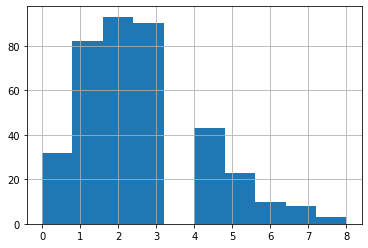

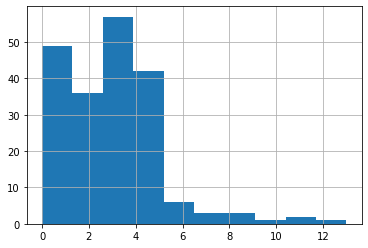

<Figure size 432x288 with 0 Axes>

In [4]:
# Determine normality using histograms
men_world_cup['total_goals'].hist()
plt.show()
plt.clf()

women_world_cup['total_goals'].hist()
plt.show()
plt.clf()


In [5]:
# Combine women's and men's data and calculate goals scored in each match
both = pd.concat([women_world_cup, men_world_cup], axis=0, ignore_index=True)

# Prep for testing
subset = both[["total_goals", "group"]]
subset_wide = subset.pivot(columns="group", values="total_goals")

In [6]:
import pingouin
from scipy.stats import mannwhitneyu

# Perform right-tailed Wilcoxon-Mann-Whitney test with pingouin
results_pg = pingouin.mwu(x=subset_wide["women"],
                          y=subset_wide["men"],
                          alternative="greater")
''
# Alternative SciPy solution: Perform right-tailed Wilcoxon-Mann-Whitney test with scipy
results_scipy = mannwhitneyu(x=women_world_cup["total_goals"],
                             y=men_world_cup["total_goals"],
                             alternative="greater")

In [7]:
# Extract p-value as a float
p_val = results_pg["p-val"].values[0]

# Determine hypothesis test result using sig. level
if p_val <= 0.01:
    result = "reject"
else:
    result = "fail to reject"

# Print results
print(f"P-value: {p_val:.4f}")
print(f"Result: {result}")

P-value: 0.0051
Result: reject


Therefore we can safely reject our hypothesis.